# Customer Behavior and Operational Performance

In this notebook, we analyze customer purchasing patterns and order fulfillment performance using the analytical dataset created during the data preparation stage.

The objectives of this analysis are to:

- Understand when customers place orders.
- Identify purchasing trends over time.
- Evaluate delivery performance.
- Explore factors influencing customer satisfaction.
- Generate actionable insights to improve customer experience and operational efficiency.

In [1]:
# Import required libraries

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
# Define project directories

PROJECT_ROOT = Path("..")

RESULTS_DIR = PROJECT_ROOT / "data" / "results"

In [3]:
# Load the analytical dataset created in Notebook 2

df = pd.read_parquet(
    RESULTS_DIR / "customer_analytics.parquet"
)

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (119143, 38)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,delivery_days,delivery_vs_estimate_days,order_month,order_year,order_day_of_week,order_hour,order_month_num
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1.0,credit_card,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0,8.0,7.0,2017-10,2017,Monday,10,10
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3.0,voucher,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0,8.0,7.0,2017-10,2017,Monday,10,10
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2.0,voucher,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,4.0,8.0,7.0,2017-10,2017,Monday,10,10
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1.0,boleto,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,4.0,13.0,5.0,2018-07,2018,Tuesday,20,7
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1.0,credit_card,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,5.0,9.0,17.0,2018-08,2018,Wednesday,8,8


In [4]:
# Ensure timestamp columns are stored as datetime

date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [5]:
# Create additional time-based features

df["purchase_year"] = (
    df["order_purchase_timestamp"]
    .dt.year
)

df["purchase_month"] = (
    df["order_purchase_timestamp"]
    .dt.month_name()
)

df["purchase_day"] = (
    df["order_purchase_timestamp"]
    .dt.day_name()
)

df["purchase_hour"] = (
    df["order_purchase_timestamp"]
    .dt.hour
)

In [6]:
# Calculate delivery performance metrics

df["delivery_days"] = (
    df["order_delivered_customer_date"]
    - df["order_purchase_timestamp"]
).dt.days

df["delivery_difference"] = (
    df["order_estimated_delivery_date"]
    - df["order_delivered_customer_date"]
).dt.days

# Positive values indicate the order was delivered before the estimated date.
# Negative values indicate the order was delivered after the estimated date.

df["delivered_on_time"] = (
    df["delivery_difference"] >= 0
)

In [7]:
# Preview engineered features

df[
    [
        "order_purchase_timestamp",
        "purchase_year",
        "purchase_month",
        "purchase_day",
        "purchase_hour",
        "delivery_days",
        "delivery_difference",
        "delivered_on_time"
    ]
].head()

,order_purchase_timestamp,purchase_year,purchase_month,purchase_day,purchase_hour,delivery_days,delivery_difference,delivered_on_time
0,2017-10-02 10:56:33,2017,October,Monday,10,8.0,7.0,True
1,2017-10-02 10:56:33,2017,October,Monday,10,8.0,7.0,True
2,2017-10-02 10:56:33,2017,October,Monday,10,8.0,7.0,True
3,2018-07-24 20:41:37,2018,July,Tuesday,20,13.0,5.0,True
4,2018-08-08 08:38:49,2018,August,Wednesday,8,9.0,17.0,True


### Part 1 - Customer Purchasing Behavior

In [8]:
# Analyze how order volume changes over time

monthly_orders = (
    df.groupby(
        df["order_purchase_timestamp"].dt.to_period("M")
    )["order_id"]
    .nunique()
    .reset_index(name="number_of_orders")
)

monthly_orders["order_purchase_timestamp"] = (
    monthly_orders["order_purchase_timestamp"]
    .astype(str)
)

monthly_orders.head()

,order_purchase_timestamp,number_of_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


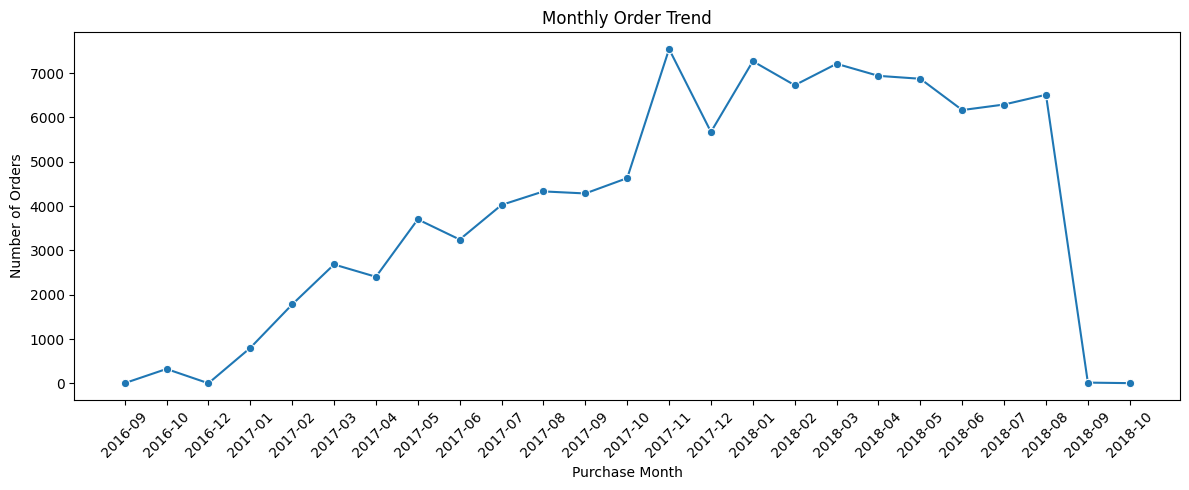

In [9]:
# Visualize monthly order volume

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_orders,
    x="order_purchase_timestamp",
    y="number_of_orders",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Order Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.show()

In [10]:
# Analyze purchasing behavior by day of week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

orders_by_day = (
    df.groupby("purchase_day")["order_id"]
    .nunique()
    .reindex(day_order)
    .reset_index(name="number_of_orders")
)

orders_by_day

,purchase_day,number_of_orders
0,Monday,16196
1,Tuesday,15963
2,Wednesday,15552
3,Thursday,14761
4,Friday,14122
5,Saturday,10887
6,Sunday,11960


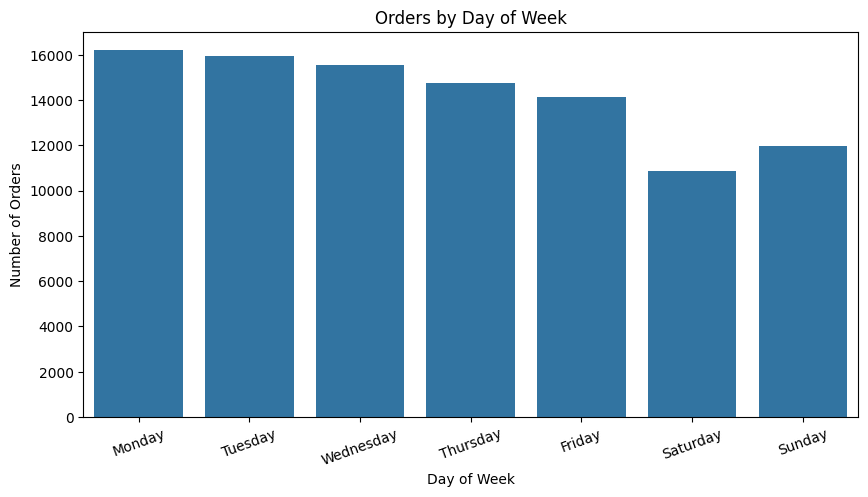

In [11]:
# Visualize purchasing activity by weekday

plt.figure(figsize=(10,5))

sns.barplot(
    data=orders_by_day,
    x="purchase_day",
    y="number_of_orders"
)

plt.title("Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")

plt.xticks(rotation=20)

plt.show()

In [12]:
# Analyze the time of day when customers place orders

orders_by_hour = (
    df.groupby("purchase_hour")["order_id"]
    .nunique()
    .reset_index(name="number_of_orders")
)

orders_by_hour.head()

,purchase_hour,number_of_orders
0,0,2394
1,1,1170
2,2,510
3,3,272
4,4,206


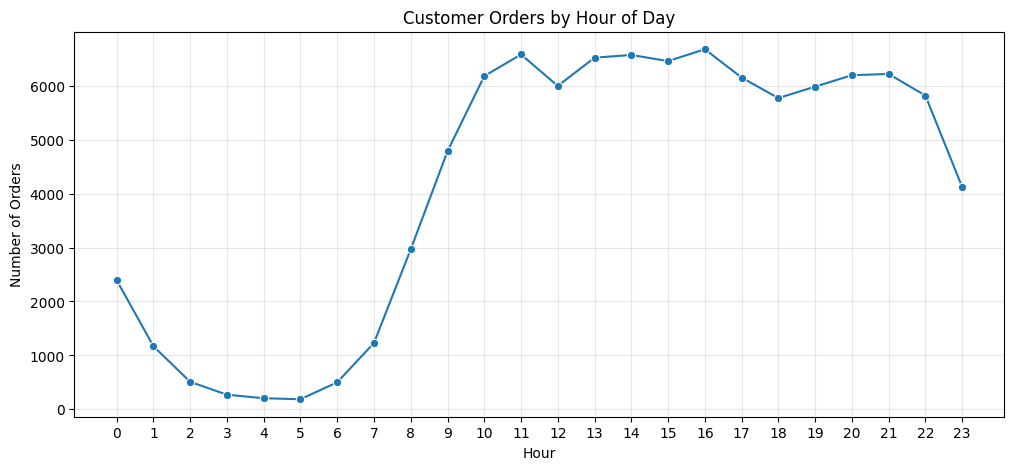

In [13]:
# Visualize hourly purchasing behavior

plt.figure(figsize=(12,5))

sns.lineplot(
    data=orders_by_hour,
    x="purchase_hour",
    y="number_of_orders",
    marker="o"
)

plt.xticks(range(24))

plt.title("Customer Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.grid(alpha=0.3)

plt.show()

In [14]:
# Create a heatmap of purchases by weekday and hour

purchase_heatmap = (
    df.groupby(
        ["purchase_day", "purchase_hour"]
    )["order_id"]
    .nunique()
    .reset_index()
)

purchase_heatmap = purchase_heatmap.pivot(
    index="purchase_day",
    columns="purchase_hour",
    values="order_id"
)

purchase_heatmap = purchase_heatmap.reindex(day_order)

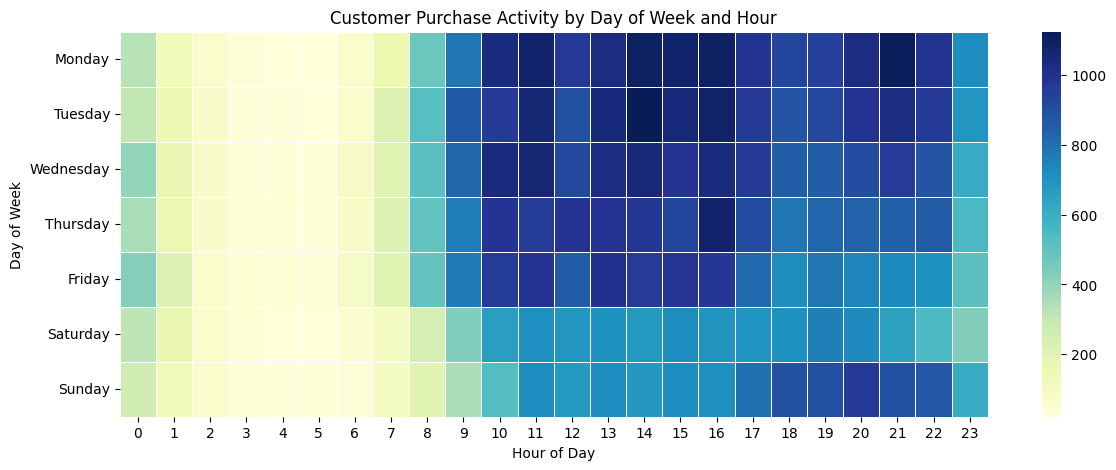

In [15]:
# Visualize customer purchasing patterns across weekdays and hours

plt.figure(figsize=(14,5))

sns.heatmap(
    purchase_heatmap,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Customer Purchase Activity by Day of Week and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

## Purchasing Behavior Summary

The purchasing behavior analysis reveals several clear customer ordering patterns across time. Monthly order volume increased steadily throughout 2017 before stabilizing during 2018, indicating continued growth in the customer base over much of the observation period. The sharp decline in the final months of the dataset is likely due to incomplete data collection rather than a true reduction in demand.

Customer purchasing activity is relatively consistent during weekdays, with **Monday** recording the highest number of orders and **Saturday** the lowest. This suggests that customers are more likely to place orders during the workweek than over the weekend.

Order activity also exhibits a strong daily pattern. Very few purchases occur during the early morning hours (2:00–6:00 AM), while activity increases rapidly beginning around **8:00 AM**. Purchasing remains consistently high throughout the day, peaking between **10:00 AM and 4:00 PM**, before gradually declining during the late evening.

The weekday-hour heatmap further highlights these trends by showing that purchasing activity is concentrated during standard business hours across all weekdays. Weekend purchasing patterns differ slightly, with lower overall activity on Saturday and a moderate increase during Sunday evening. These findings suggest that marketing campaigns, customer support resources, and operational capacity should be aligned with peak daytime purchasing periods to maximize customer engagement and service efficiency.

### Part 2 - Delivery Performance

## Delivery Performance

Delivery performance is a critical component of the customer experience in e-commerce. In this section, we analyze delivery times, compare actual deliveries against estimated delivery dates, and identify operational patterns that may influence customer satisfaction.

In [17]:
# Summary statistics for delivery time

df["delivery_days"].describe().round(2)

count    115722.00
mean         12.02
std           9.45
min           0.00
25%           6.00
50%          10.00
75%          15.00
max         209.00
Name: delivery_days, dtype: float64

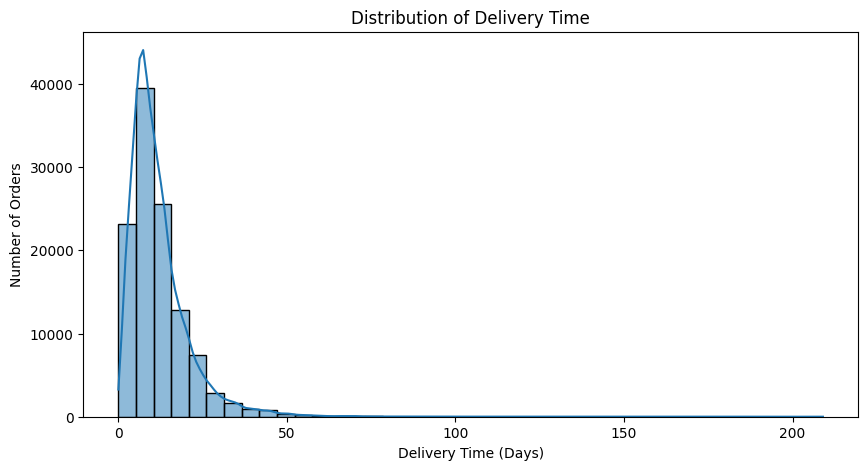

In [18]:
# Distribution of delivery times

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="delivery_days",
    bins=40,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

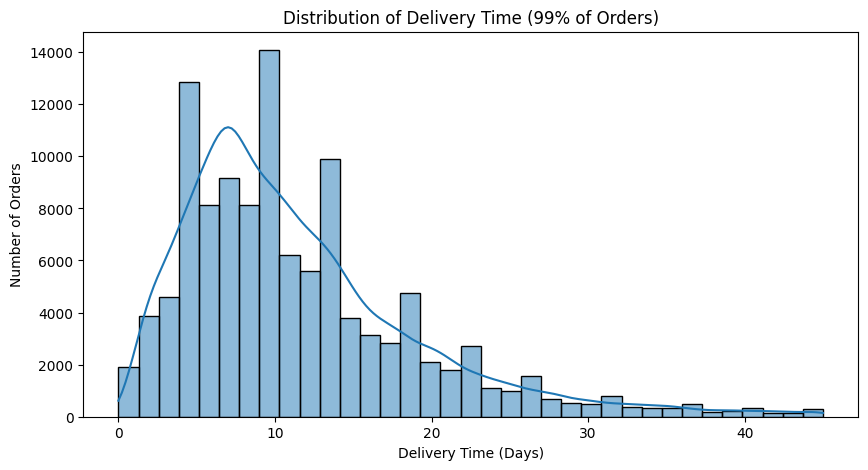

In [19]:
# Focus on the 99% of deliveries

upper = df["delivery_days"].quantile(0.99)

plt.figure(figsize=(10,5))

sns.histplot(
    data=df[df["delivery_days"] <= upper],
    x="delivery_days",
    bins=35,
    kde=True
)

plt.title("Distribution of Delivery Time (99% of Orders)")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

In [20]:
# Percentage of on-time deliveries

delivery_summary = (
    df["delivered_on_time"]
    .value_counts()
    .rename_axis("Delivered On Time")
    .reset_index(name="Orders")
)

delivery_summary

,Delivered On Time,Orders
0,True,106654
1,False,12489


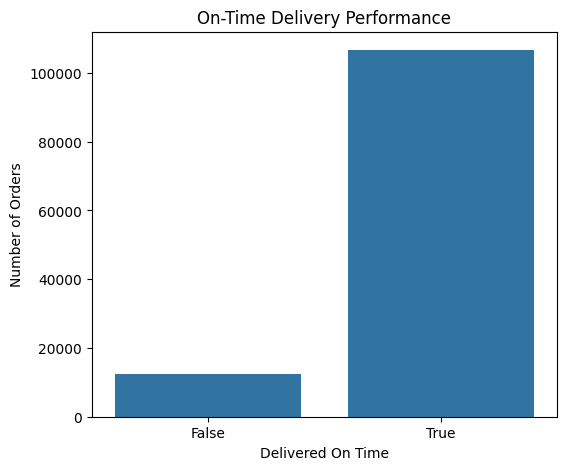

In [21]:
# Visualize on-time delivery performance

plt.figure(figsize=(6,5))

sns.barplot(
    data=delivery_summary,
    x="Delivered On Time",
    y="Orders"
)

plt.title("On-Time Delivery Performance")
plt.xlabel("Delivered On Time")
plt.ylabel("Number of Orders")

plt.show()

In [22]:
# Average delivery time by customer state

state_delivery = (
    df.groupby("customer_state")
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        orders=("order_id", "nunique")
    )
    .query("orders >= 100")
    .sort_values("average_delivery_days", ascending=False)
)

state_delivery.head()

,average_delivery_days,orders
customer_state,,
AM,26.064706,148
AL,24.128090,413
PA,23.268004,975
MA,21.191981,747
SE,20.886010,350


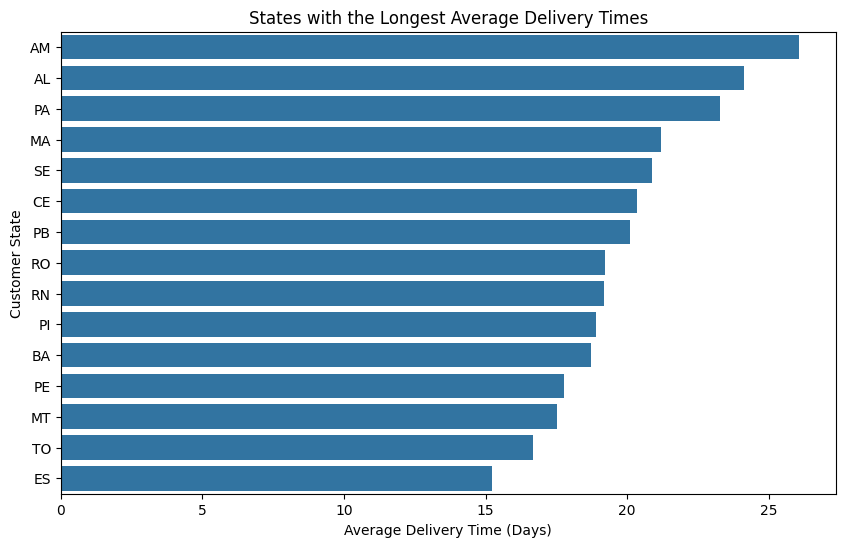

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=state_delivery.head(15).reset_index(),
    x="average_delivery_days",
    y="customer_state"
)

plt.title("States with the Longest Average Delivery Times")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Customer State")

plt.show()

In [24]:
# Product categories with longest delivery times

category_delivery = (
    df.groupby("product_category_name")
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        orders=("order_id", "nunique")
    )
    .query("orders >= 200")
    .sort_values("average_delivery_days", ascending=False)
)

category_delivery.head(15)

,average_delivery_days,orders
product_category_name,,
moveis_escritorio,20.505389,1273
fashion_calcados,14.809524,240
moveis_sala,13.591603,422
ferramentas_jardim,13.262946,3518
eletrodomesticos_2,13.171103,234
consoles_games,13.128070,1062
casa_conforto,12.947146,397
audio,12.854881,350
informatica_acessorios,12.805325,6689


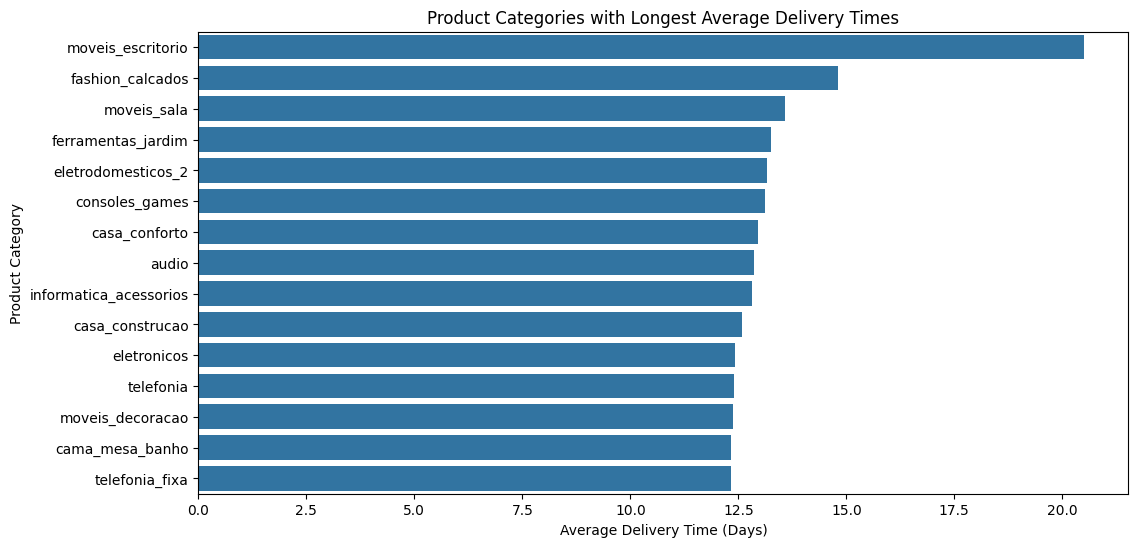

In [25]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_delivery.head(15).reset_index(),
    x="average_delivery_days",
    y="product_category_name"
)

plt.title("Product Categories with Longest Average Delivery Times")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Product Category")

plt.show()

## Delivery Performance Summary

The average delivery time across all orders was **12 days**, with half of all deliveries completed within **10 days**. While most orders arrived within two weeks, delivery times varied considerably, ranging from same-day delivery to over **200 days** in a small number of exceptional cases.

Overall, delivery performance was strong, with **89.5% of orders delivered on or before the estimated delivery date**. The average difference between the estimated and actual delivery date was **11 days**, indicating that most orders arrived well before the promised delivery date. However, a small number of deliveries occurred significantly later than expected, highlighting occasional operational challenges.

Delivery performance also varied across geographic regions. Customers in states such as **Amazonas (AM)**, **Alagoas (AL)**, and **Pará (PA)** experienced the longest average delivery times, often exceeding **20 days**. These differences are likely influenced by transportation distance, regional infrastructure, and logistical complexity.

At the product level, larger and more difficult-to-ship categories generally required longer delivery times. Categories such as **office furniture (moveis_escritorio)**, **fashion footwear (fashion_calcados)**, and **living room furniture (moveis_sala)** recorded the highest average delivery durations, while high-volume categories such as **computer accessories** and **garden tools** maintained relatively competitive delivery performance despite processing thousands of orders.

Overall, the results indicate that the fulfillment network performs reliably for the majority of customers while identifying specific regions and product categories where targeted operational improvements could further reduce delivery times and enhance the customer experience.

### Part 3 - Customer Satisfaction

## Customer Satisfaction

Customer satisfaction is measured using review scores submitted after order delivery. In this section, we investigate how operational factors such as delivery time and delivery delays influence customer ratings and identify opportunities to improve the customer experience.

In [31]:
# Distribution of customer review scores

review_dist = (
    df["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_dist.columns = ["review_score", "orders"]

review_dist

,review_score,orders
0,1.0,15428
1,2.0,4162
2,3.0,9894
3,4.0,22319
4,5.0,66343


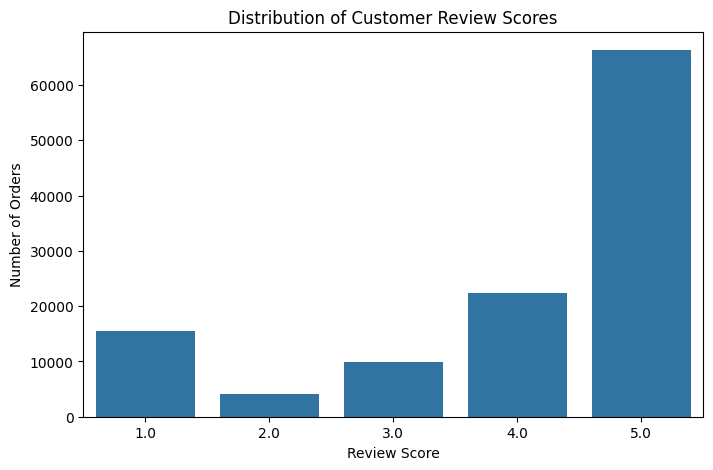

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=review_dist,
    x="review_score",
    y="orders"
)

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")

plt.show()

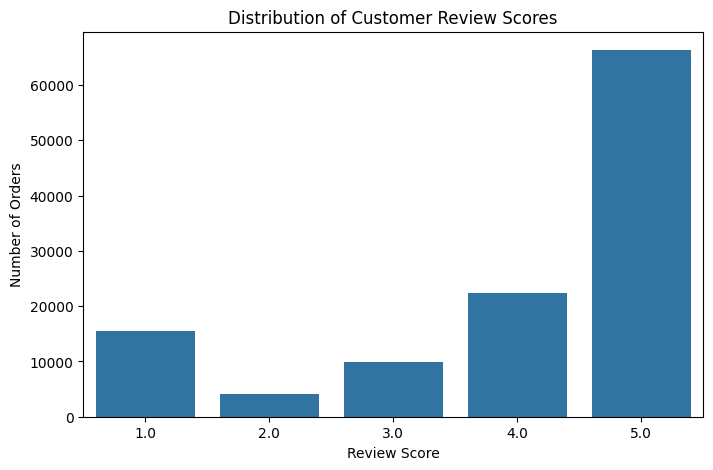

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=review_dist,
    x="review_score",
    y="orders"
)

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Orders")

plt.show()

In [34]:
print(
    f"Average Review Score: {df['review_score'].mean():.2f}"
)

Average Review Score: 4.02


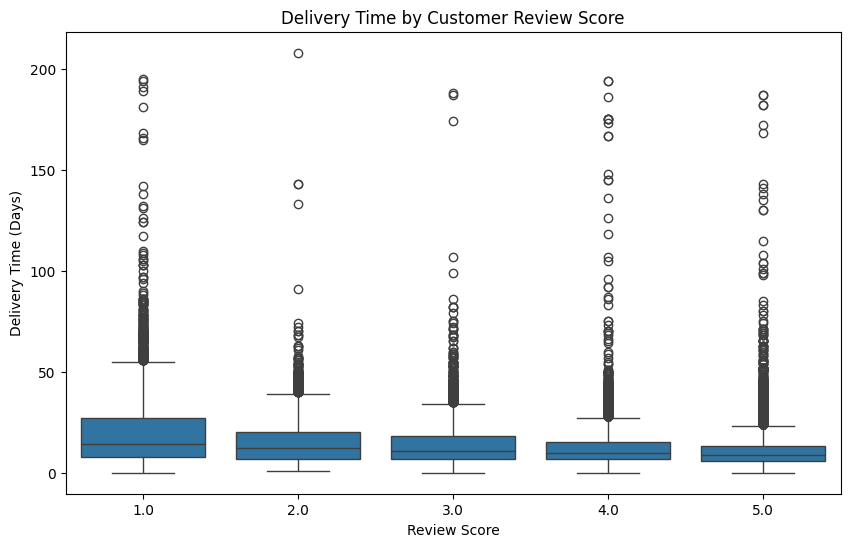

In [35]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="review_score",
    y="delivery_days"
)

plt.title("Delivery Time by Customer Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Time (Days)")

plt.show()

In [36]:
delivery_review = (
    df.groupby("review_score")
    .agg(
        average_delivery_days=("delivery_days", "mean"),
        orders=("order_id", "nunique")
    )
    .round(2)
)

delivery_review

,average_delivery_days,orders
review_score,,
1.0,19.10,11393
2.0,15.38,3148
3.0,13.55,8160
4.0,11.78,19098
5.0,10.20,57076


In [37]:
review_ontime = (
    df.groupby("delivered_on_time")
    .agg(
        average_review=("review_score", "mean"),
        orders=("order_id", "nunique")
    )
    .round(2)
)

review_ontime

,average_review,orders
delivered_on_time,,
False,2.33,10792
True,4.21,88649


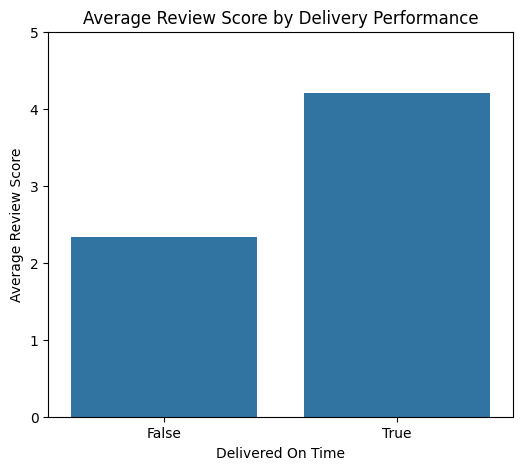

In [38]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=review_ontime.reset_index(),
    x="delivered_on_time",
    y="average_review"
)

plt.title("Average Review Score by Delivery Performance")
plt.xlabel("Delivered On Time")
plt.ylabel("Average Review Score")

plt.ylim(0,5)

plt.show()

In [39]:
category_reviews = (
    df.groupby("product_category_name")
    .agg(
        average_review=("review_score","mean"),
        orders=("order_id","nunique")
    )
    .query("orders >= 200")
    .sort_values("average_review")
)

category_reviews.head(10)

,average_review,orders
product_category_name,,
moveis_escritorio,3.526791,1273
telefonia_fixa,3.672862,217
audio,3.840849,350
cama_mesa_banho,3.890605,9417
casa_conforto,3.907563,397
moveis_decoracao,3.912158,6449
moveis_sala,3.913793,422
artes,3.935484,202
informatica_acessorios,3.936089,6689


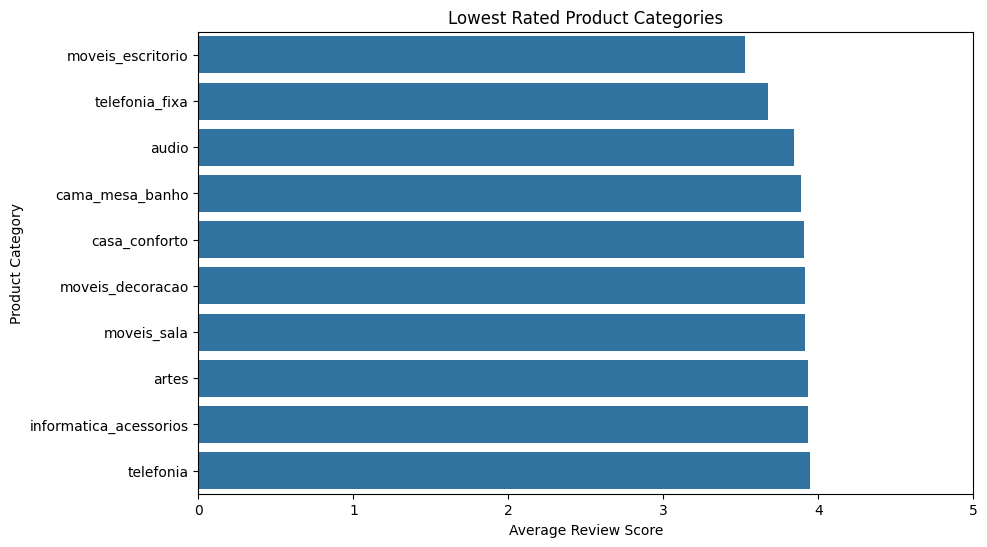

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=category_reviews.head(10).reset_index(),
    x="average_review",
    y="product_category_name"
)

plt.title("Lowest Rated Product Categories")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.xlim(0,5)

plt.show()

In [41]:
category_reviews.tail(10)

,average_review,orders
product_category_name,,
eletrodomesticos,4.174970,764
papelaria,4.188339,2311
pet_shop,4.197030,1710
eletrodomesticos_2,4.212687,234
fashion_calcados,4.223443,240
alimentos,4.228963,450
malas_acessorios,4.295945,1034
alimentos_bebidas,4.324138,227
livros_tecnicos,4.375465,260


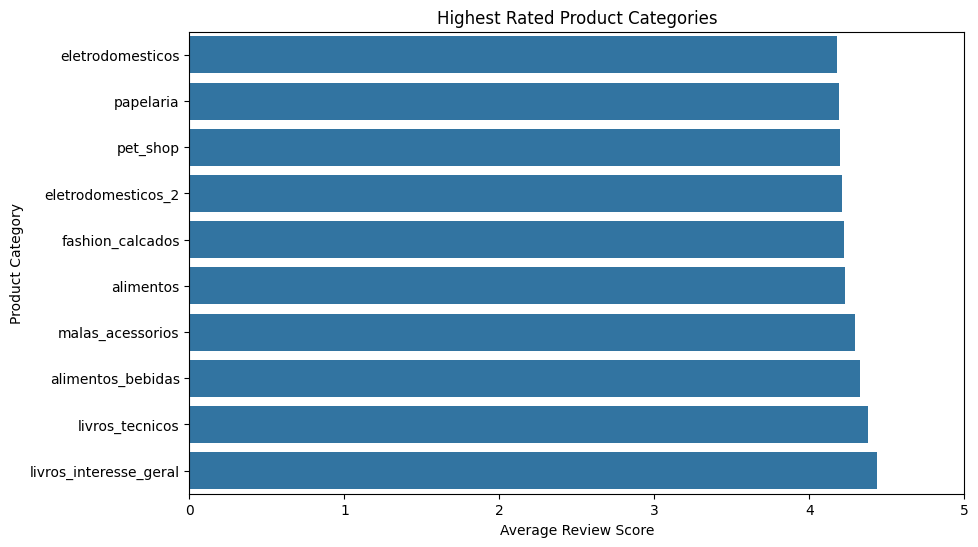

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=category_reviews.tail(10).reset_index(),
    x="average_review",
    y="product_category_name"
)

plt.title("Highest Rated Product Categories")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.xlim(0,5)

plt.show()

In [43]:
state_reviews = (
    df.groupby("customer_state")
    .agg(
        average_review=("review_score","mean"),
        orders=("order_id","nunique")
    )
    .query("orders >= 100")
    .sort_values("average_review")
)

state_reviews.head(10)

,average_review,orders
customer_state,,
MA,3.670588,747
AL,3.715835,413
PA,3.786101,975
SE,3.795511,350
RJ,3.799830,12852
BA,3.807235,3380
CE,3.810167,1336
PI,3.849123,495
MT,3.890277,907


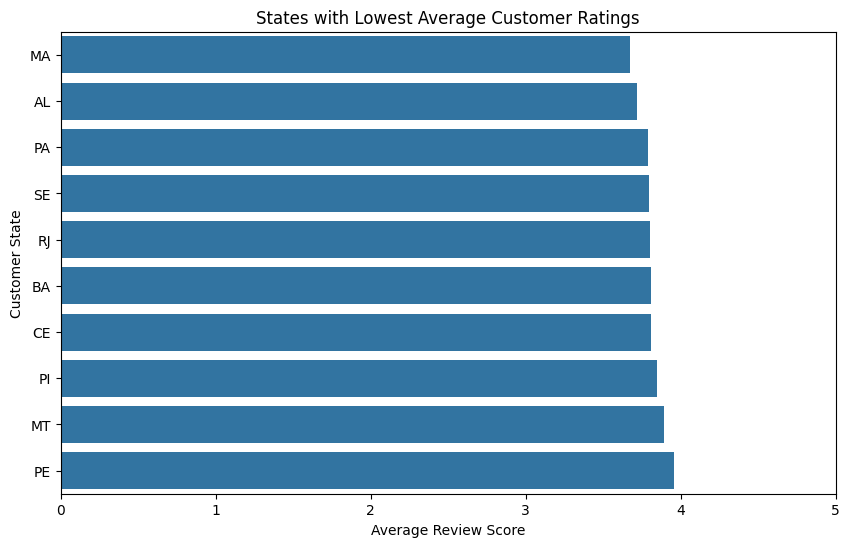

In [44]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=state_reviews.head(10).reset_index(),
    x="average_review",
    y="customer_state"
)

plt.title("States with Lowest Average Customer Ratings")
plt.xlabel("Average Review Score")
plt.ylabel("Customer State")

plt.xlim(0,5)

plt.show()

## Customer Satisfaction Summary

Customer satisfaction is generally high, with an average review score of **4.02 out of 5**. More than **57%** of all orders received the highest possible rating (**5 stars**), while approximately **13%** received a **1-star** review. This indicates that most customers had a positive shopping experience, although a notable minority experienced significant dissatisfaction.

Delivery performance emerged as one of the strongest drivers of customer satisfaction. Orders delivered **on or before the estimated delivery date** received an average review score of **4.21**, whereas **late deliveries** averaged only **2.33**. This nearly **two-point difference** highlights the importance of meeting delivery commitments in maintaining a positive customer experience.

Delivery duration also exhibited a clear relationship with customer ratings. Customers who awarded **5-star** ratings received their orders in an average of **10.2 days**, compared with **19.1 days** for customers leaving **1-star** reviews. The boxplot further confirms this trend, showing that both the median delivery time and the variability in delivery duration decrease as customer ratings improve.

Customer satisfaction varied across product categories. Categories such as **Office Furniture**, **Fixed Telephony**, and **Audio** received the lowest average ratings, while **Books**, **Food & Beverages**, and **Luggage & Accessories** consistently achieved the highest customer satisfaction. These differences may reflect variations in product quality, shipping complexity, or customer expectations.

Regional differences were also observed. States including **Maranhão (MA)**, **Alagoas (AL)**, and **Pará (PA)** recorded the lowest average review scores, while **São Paulo (SP)**, **Paraná (PR)**, and **Tocantins (TO)** reported the highest customer satisfaction. These findings are consistent with the delivery performance analysis, suggesting that fulfillment efficiency plays an important role in shaping customer perceptions across different regions.

Overall, the analysis demonstrates a strong relationship between operational performance and customer satisfaction. Reducing delivery delays and consistently meeting promised delivery dates are likely to improve customer ratings, particularly in regions and product categories where customer satisfaction currently lags.